### Final Project

In [244]:
#Imported Libraries
import os
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [245]:
# Web scraped the SPY etf ticker's data from an excel file within a download link. 
stocks = pd.read_excel('https://www.ssga.com/us/en/intermediary/etfs/library-content/products/fund-data/etfs/us/holdings-daily-us-en-spy.xlsx',
                        header=4).Ticker.dropna().to_list()

stocks = [ticker.upper() for ticker in stocks] 

# Gathers asset's data from past 5 years (1825 days) to today 
start_date = dt.datetime.today() - pd.Timedelta(1825, "d")
end_date = dt.datetime.today()

# Downloads stock data
data =yf.download (start=start_date,end=end_date, tickers= stocks, auto_adjust=False)['Adj Close']
data= pd.DataFrame(data).dropna(how='all', axis=1) 

data2 =yf.download (start=start_date,end=end_date, tickers= stocks, auto_adjust=False )
data2= pd.DataFrame(data2).dropna(how='all', axis=1)

data3 =yf.download (start=start_date,end=end_date, tickers= stocks , auto_adjust=False)['Volume'] #for volume trend line
data3= pd.DataFrame(data3).dropna(how='all', axis=1) 

[*********************100%***********************]  505 of 505 completed

4 Failed downloads:
['BRK.B', '-', '2602335D']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-06-21 16:19:05.754959 -> 2026-06-20 16:19:05.755010)')
[*********************100%***********************]  505 of 505 completed

4 Failed downloads:
['BRK.B', '-', '2602335D']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-06-21 16:19:05.754959 -> 2026-06-20 16:19:05.755010)')
[*********************100%***********************]  505 of 505 completed

4 Failed downloads:
['BRK.B', '-', '2602335D']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-06-21 16:19:05.754959 -> 2026-06-20 16:19:05.755010)')


52 weeks trendline slopes

In [246]:
trend_slopes = {}

for ticker in data.columns:

    y = data[ticker].shift(20).dropna()

    # Require at least 252 observations
    if len(y) < 252:
        continue

    y = y.iloc[-252:]
    x = np.arange(len(y))

    trend_slopes[ticker] = np.polyfit(x, y, 1)[0]

trend_slopes = pd.Series(trend_slopes)
trend_slopes

A       0.010264
AAPL    0.315871
ABBV    0.128811
ABNB    0.010874
ABT    -0.161364
          ...   
XYZ    -0.031930
YUM     0.078547
ZBH    -0.031644
ZBRA   -0.457118
ZTS    -0.237175
Length: 499, dtype: float64

Percent above 260 day low

In [247]:
lagged_close = data2['Close'].shift(20)
lagged_low = data2['Low'].shift(20)

current_price = lagged_close.iloc[-1]
lowest_price = lagged_low.iloc[-260:].min()

percentabove_lows = ((current_price - lowest_price) / lowest_price) * 100
percentabove_lows

Ticker
A        6.785542
AAPL    56.233841
ABBV    20.235597
ABNB    22.326510
ABT      7.819929
          ...    
XYZ     47.303895
YUM     11.199304
ZBH      7.912025
ZBRA    22.316000
ZTS     10.127110
Length: 501, dtype: float64

4/52 week price oscillator

In [248]:
close = data2['Close']

# 52-week Exponential Moving Average (EMA)
ema_52w = close.ewm(span=252, min_periods=252).mean()

# 4-week EMA
ema_4w = close.ewm(span=20, min_periods=20).mean()

# 20-day lag
price_oscillator = ((ema_4w.shift(20) - ema_52w.shift(20))
                    / ema_52w.shift(20)) * 100

# Last available values
price_oscillator = price_oscillator.iloc[-1].dropna()

price_oscillator

Ticker
A       -9.418041
AAPL    13.203751
ABBV    -1.454243
ABNB     4.086729
ABT    -22.263805
          ...    
XYZ      5.180591
YUM      1.380201
ZBH     -9.750916
ZBRA    -8.968996
ZTS    -29.537407
Name: 2026-06-18 00:00:00, Length: 499, dtype: float64

39 week returns

In [249]:
weekreturns = (data.shift(20).pct_change(195))

weekreturns = weekreturns.iloc[-1]
weekreturns

/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/2750151052.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  weekreturns = (data.shift(20).pct_change(195))


Ticker
A       0.003004
AAPL    0.334207
ABBV    0.094136
ABNB    0.145816
ABT    -0.316516
          ...   
XYZ    -0.029303
YUM     0.096401
ZBH    -0.139677
ZBRA   -0.220771
ZTS    -0.458606
Name: 2026-06-18 00:00:00, Length: 501, dtype: float64

51 week volume price trend

In [250]:
# Prices and volume
close = data2['Close']
volume = data2['Volume']

# Daily returns
returns = close.pct_change()

# Volume Price Trend series
vpt = (returns * volume).cumsum()

# Apply 20-day lag
vpt_lag20 = vpt.shift(20)

# Current factor value for each stock
vpt_factor = vpt_lag20.iloc[-1]

vpt_factor


/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/2144087098.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close.pct_change()


Ticker
A      -5.208914e+05
AAPL    7.784530e+07
ABBV   -3.998109e+06
ABNB    3.494996e+06
ABT    -7.743391e+06
            ...     
XYZ     6.299038e+06
YUM     1.031943e+06
ZBH    -3.807427e+06
ZBRA   -9.092247e+05
ZTS    -1.269485e+07
Name: 2026-06-18 00:00:00, Length: 501, dtype: float64

Z-scores

In [251]:
factors = pd.DataFrame({
    'trendline': trend_slopes,
    'above_low': percentabove_lows,
    'oscillator': price_oscillator,
    'return_39weeks': weekreturns,
    'volpricetrend': vpt_factor
})

factors = factors.dropna()# removes stocks with no data
factors

,trendline,above_low,oscillator,return_39weeks,volpricetrend
A,0.010264,6.785542,-9.418041,0.003004,-5.208914e+05
AAPL,0.315871,56.233841,13.203751,0.334207,7.784530e+07
ABBV,0.128811,20.235597,-1.454243,0.094136,-3.998109e+06
ABNB,0.010874,22.326510,4.086729,0.145816,3.494996e+06
ABT,-0.161364,7.819929,-22.263805,-0.316516,-7.743391e+06
...,...,...,...,...,...
XYZ,-0.031930,47.303895,5.180591,-0.029303,6.299038e+06
YUM,0.078547,11.199304,1.380201,0.096401,1.031943e+06
ZBH,-0.031644,7.912025,-9.750916,-0.139677,-3.807427e+06
ZBRA,-0.457118,22.316000,-8.968996,-0.220771,-9.092247e+05


In [252]:
# Calculates z-scores
zscores = factors.apply(
    lambda x: (x - x.mean()) / x.std(),
    axis=0
)

# Calculate composite momentum score
composite_score = zscores.mean(axis=1)
composite_score

A      -0.258710
AAPL    0.283383
ABBV   -0.127183
ABNB   -0.092455
ABT    -0.488226
          ...   
XYZ    -0.090326
YUM    -0.116643
ZBH    -0.298937
ZBRA   -0.423838
ZTS    -0.606025
Length: 499, dtype: float64

10 Long and Short Baskets

In [253]:
long_assets = composite_score.nlargest(10)
short_assets = composite_score.nsmallest(10)

print("Longs")
print(long_assets)

print("\nShorts")
print(short_assets)

Longs
SNDK    10.654011
LITE     4.024616
NVDA     3.078305
MU       3.003045
INTC     2.931880
WDC      2.894453
CVNA     2.806049
FIX      2.744569
STX      2.674897
CIEN     2.625283
dtype: float64

Shorts
NVR    -1.943860
FICO   -1.159186
AXON   -1.063516
INTU   -1.057069
IT     -0.910099
FISV   -0.906508
TYL    -0.884116
AZO    -0.868178
CHTR   -0.835252
TTD    -0.823126
dtype: float64


Backtest

In [254]:
month_ends = data.resample('ME').last().index
print(len(month_ends))
print(month_ends.min(), month_ends.max())

61
2021-06-30 00:00:00 2026-06-30 00:00:00


In [255]:
portfolio_returns = []
long_returns = []
short_returns = []
dates = []

warmup = min(24, len(month_ends)//3)
for i in range(warmup, len(month_ends)-1):

    signal_date = month_ends[i]
    next_month = month_ends[i+1]

    # Use only information available on signal date
    hist_prices = data.loc[:signal_date]
    hist_close = data2['Close'].loc[:signal_date]
    hist_low = data2['Low'].loc[:signal_date]
    hist_volume = data2['Volume'].loc[:signal_date]
    
    #Trendline
    trend_slopes = {}

    for ticker in hist_prices.columns:

        y = hist_prices[ticker].shift(20).dropna()

        if len(y) < 252:
            continue

        y = y.iloc[-252:]
        x = np.arange(252)

        trend_slopes[ticker] = np.polyfit(x, y, 1)[0]

    trend_slopes = pd.Series(trend_slopes)
    
    # Percent above low
    current_price = hist_close.shift(20).iloc[-1]
    lowest_price = hist_low.shift(20).iloc[-260:].min()

    above_low = (
        (current_price-lowest_price)
        / lowest_price
    )*100
    
    # Price oscillator
    ema_52 = hist_close.ewm(span=252).mean()
    ema_4 = hist_close.ewm(span=20).mean()

    oscillator = (
        (ema_4.shift(20)-ema_52.shift(20))
        / ema_52.shift(20)
    )*100

    oscillator = oscillator.iloc[-1]
    
    # 39-week return
    ret39 = hist_prices.shift(20).pct_change(195)
    ret39 = ret39.iloc[-1]
    
    # VPT
    vpt = (
    hist_close.pct_change()* hist_volume).cumsum()

    vpt = vpt.shift(20).iloc[-1]
    
    # Composite score
    factors = pd.DataFrame({
        'trend': trend_slopes,
        'above_low': above_low,
        'oscillator': oscillator,
        'ret39': ret39,
        'vpt': vpt})

    factors = factors.dropna()

    zscores = factors.apply(lambda x: (x-x.mean())/x.std())

    composite = zscores.mean(axis=1)
    
    # Portfolio
    longs = composite.nlargest(10).index
    shorts = composite.nsmallest(10).index
    
    # Next month's return
    start_prices = hist_prices.iloc[-1][factors.index]
    end_prices = data.loc[:next_month].iloc[-1][factors.index]

    monthly_returns = (end_prices / start_prices - 1)

    # Long Portfolio
    long_return = monthly_returns[longs].mean()
    # Short Portfolio
    short_return = -monthly_returns[shorts].mean()
    # Neutral Portfolio
    portfolio_return = (long_return + short_return) / 2
    
    # Results
    long_returns.append(long_return)
    short_returns.append(short_return)
    portfolio_returns.append(portfolio_return)
    dates.append(next_month)  
    
# Return series
portfolio_returns = pd.Series(portfolio_returns, index=dates)

#Cumulative returns
cumulative = (1 + portfolio_returns).cumprod()

print(portfolio_returns.head())
print(portfolio_returns.describe())
    

/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/1387674816.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret39 = hist_prices.shift(20).pct_change(195)
/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/1387674816.py:61: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  hist_close.pct_change()* hist_volume).cumsum()
/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/1387674816.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA valu

2023-03-31   -0.004513
2023-04-30   -0.016674
2023-05-31    0.035977
2023-06-30   -0.016699
2023-07-31    0.034327
dtype: float64
count    40.000000
mean      0.030731
std       0.056739
min      -0.050345
25%      -0.007421
50%       0.023458
75%       0.058439
max       0.213219
dtype: float64


/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/1387674816.py:61: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  hist_close.pct_change()* hist_volume).cumsum()


In [256]:
# Performance 
perf = pd.DataFrame({
    'Portfolio': portfolio_returns,
    'Long': long_returns,
    'Short': short_returns
}, index=dates)

spy = yf.download('SPY',
    start=start_date,
    end=end_date,
    auto_adjust=True
)['Close']
# Create ETF benchmark returns
spy_monthly = spy.resample('M').last().pct_change().dropna()

perf['SPY'] = spy_monthly.reindex(perf.index)

perf = perf.dropna()


[*********************100%***********************]  1 of 1 completed
/var/folders/q9/1h42_3tn705_j_750qfm6dz00000gn/T/ipykernel_20122/2239835322.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spy_monthly = spy.resample('M').last().pct_change().dropna()


Charts

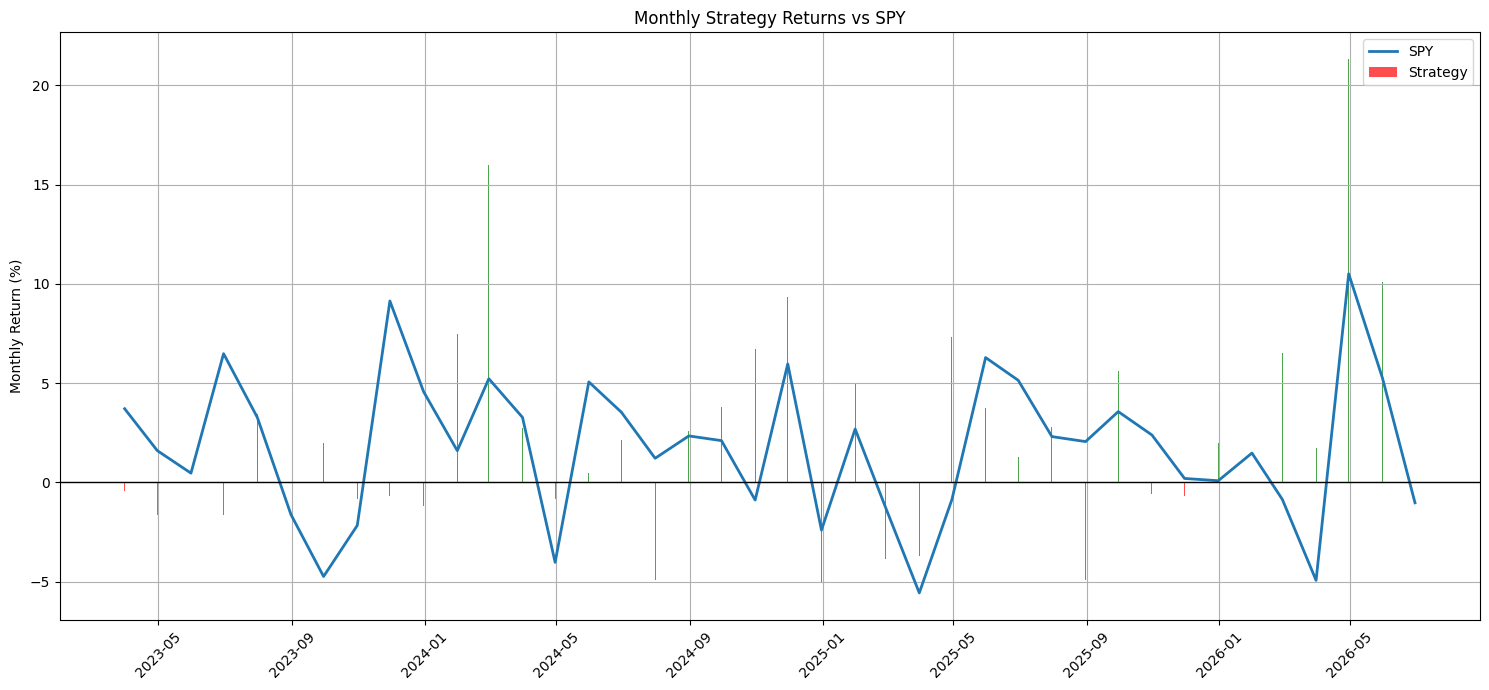

In [257]:
# Chart 1
fig, ax = plt.subplots(figsize=(15,7))

colors = ['green' if x >= 0 else 'red'
        for x in perf['Portfolio']]

ax.bar(
    perf.index,
    perf['Portfolio']*100,
    color=colors,
    alpha=0.7,
    label='Strategy'
)

ax.plot(
    perf.index,
    perf['SPY']*100,
    linewidth=2,
    label='SPY'
)

ax.axhline(0,color='black',linewidth=1)

ax.set_title('Monthly Strategy Returns vs SPY')
ax.set_ylabel('Monthly Return (%)')

ax.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

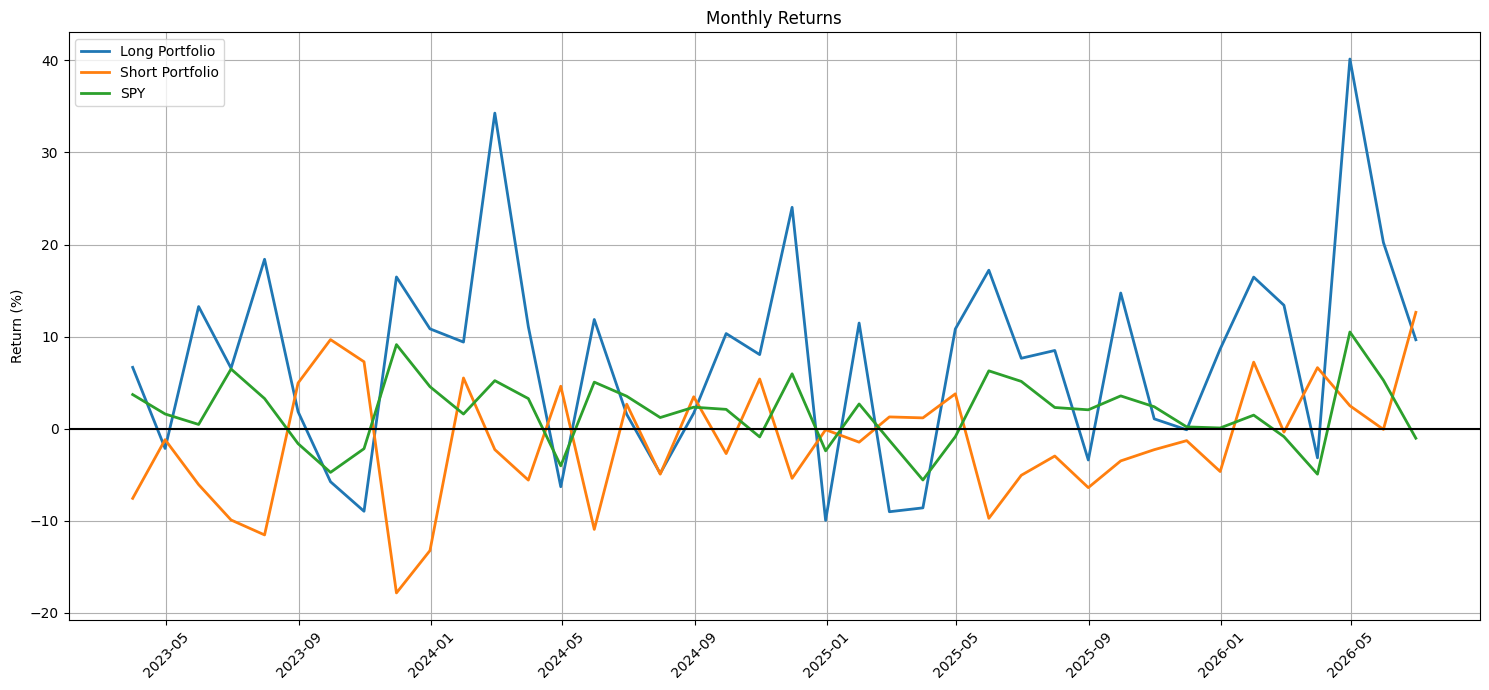

In [258]:
# Chart 2
fig, ax = plt.subplots(figsize=(15,7))

ax.plot(
    perf.index,
    perf['Long']*100,
    label='Long Portfolio',
    linewidth=2
)

ax.plot(
    perf.index,
    perf['Short']*100,
    label='Short Portfolio',
    linewidth=2
)

ax.plot(
    perf.index,
    perf['SPY']*100,
    label='SPY',
    linewidth=2
)

ax.axhline(0,color='black')

ax.set_title('Monthly Returns')
ax.set_ylabel('Return (%)')

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

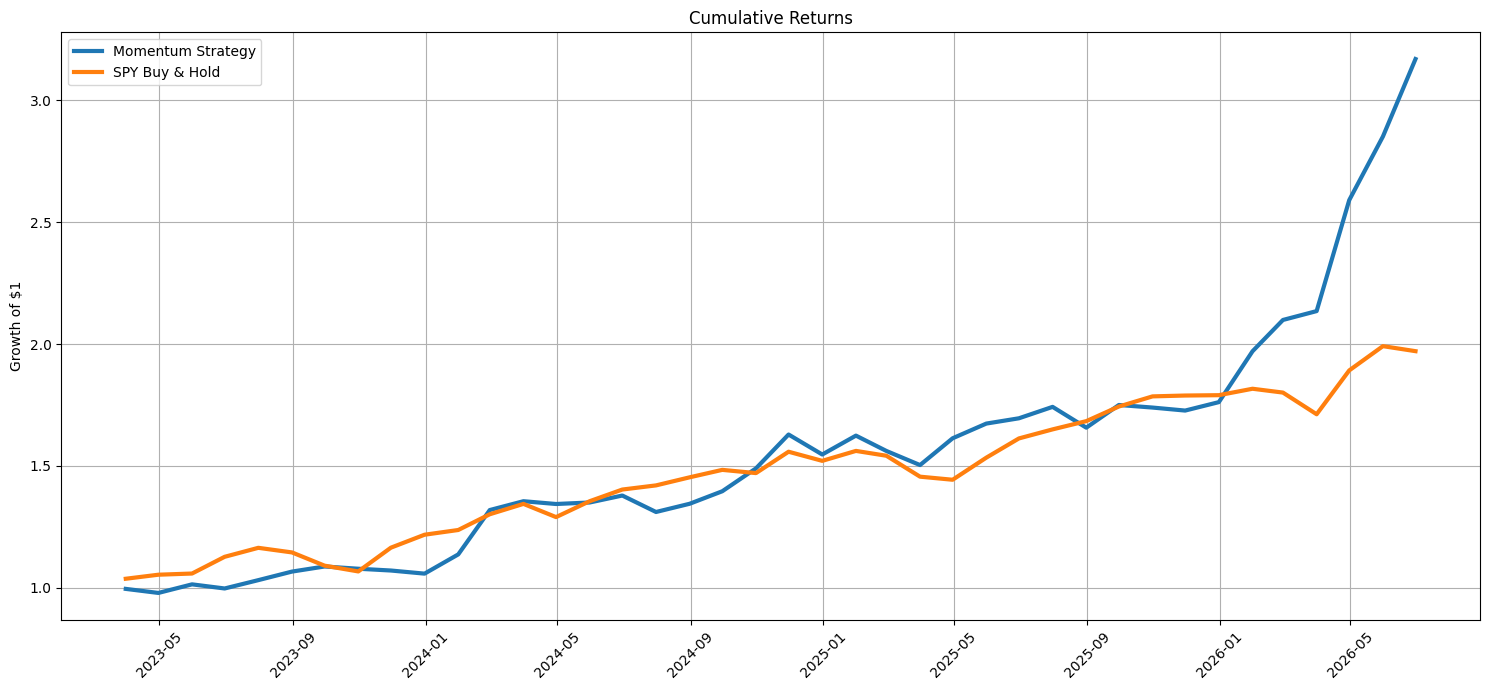

In [259]:
#Chart 3
cumulative = (1 + perf[['Portfolio','SPY']]).cumprod()

fig, ax = plt.subplots(figsize=(15,7))

ax.plot(
    cumulative.index,
    cumulative['Portfolio'],
    linewidth=3,
    label='Momentum Strategy'
)

ax.plot(
    cumulative.index,
    cumulative['SPY'],
    linewidth=3,
    label='SPY Buy & Hold'
)

ax.set_title('Cumulative Returns')
ax.set_ylabel('Growth of $1')

ax.legend()

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


## Data Export

In [260]:
perf_export = perf.copy()
perf_export["Cumulative"] = (1 + perf_export["Portfolio"]).cumprod()

perf_export.to_csv("momentum_backtest_results.csv")